# EDA consolidado — Qué features predicen la recompra

**Data Analyst · Anastasia Ganderats · Daily 2 / 3**

Este notebook corre sobre la **base analítica procesada** (`data/processed/*.parquet`) del pipeline,
no sobre los CSV crudos. Su objetivo es responder la pregunta abierta de Julieta: **¿qué variables
tienen señal para el modelo? (algunas ya se incorporaron después)**

Para eso mide, sobre los pares usuario-producto conocidos de los usuarios evaluables, la **probabilidad
de que el producto vuelva a comprarse** (aparezca en el pedido objetivo `train`) en función de cada
feature. Cada sección cierra en una decisión de modelado.

> Requisito: generar antes las tablas con `python src/data/build_dataset.py`. Corre en DuckDB, liviano.


In [1]:
%matplotlib inline
import os
from pathlib import Path
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def _root(p=Path.cwd().resolve()):
    for c in [p,*p.parents]:
        if (c/"data"/"processed").exists() or (c/".git").exists(): return c
    return p
ROOT = _root()
PROC = Path(os.environ["INSTACART_PROCESSED"]) if os.environ.get("INSTACART_PROCESSED") else ROOT/"data"/"processed"
assert (PROC/"interacciones.parquet").exists(), f"No encuentro los parquet en {PROC}. Corré: python src/data/build_dataset.py"
FIG = ROOT/"reports"/"figures"; FIG.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(); con.execute("PRAGMA threads=2; PRAGMA memory_limit='3GB'; PRAGMA disable_progress_bar;")
for t in ["catalogo","usuarios","productos","interacciones","targets_train"]:
    con.execute(f"CREATE VIEW {t} AS SELECT * FROM '{(PROC/(t+'.parquet')).as_posix()}'")
sql=lambda q: con.execute(q).fetchdf()

# Paleta: solo azul / blanco / rojo (sin gris)
AZUL, AZUL_OSC, AZUL_MED, AZUL_CLARO = "#12408f","#0a2a5e","#2e67c4","#a9c7ea"
ROJO, TINTA, TINTA2, GRILLA, EJE = "#e4002b","#0a2340","#39568c","#e3ebf6","#c2d6ef"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
 "font.size":10,"figure.dpi":110,"axes.prop_cycle":plt.cycler(color=[AZUL,ROJO,AZUL_MED,AZUL_CLARO])})
def ejes(ax,t="",s="",xlab="",ylab="",grid="y"):
    for sp in ("top","right"): ax.spines[sp].set_visible(False)
    for sp in ("left","bottom"): ax.spines[sp].set_color(EJE)
    ax.tick_params(colors=TINTA2,length=0,labelsize=9)
    if grid: ax.grid(axis=grid,color=GRILLA,linewidth=.9); ax.set_axisbelow(True)
    if xlab: ax.set_xlabel(xlab,color=TINTA2,fontsize=9.5)
    if ylab: ax.set_ylabel(ylab,color=TINTA2,fontsize=9.5)
    if t: ax.set_title(t,color=TINTA,fontsize=12,fontweight="bold",loc="left",pad=16 if s else 9)
    if s: ax.text(0,1.02,s,transform=ax.transAxes,color=TINTA2,fontsize=9.2,va="bottom")
    return ax
pct=lambda x,p=None: f"{x:.0%}"
def guardar(fig,n): fig.savefig(FIG/f"{n}.png",dpi=140,bbox_inches="tight"); print("figura →",FIG/f"{n}.png")
print("Tablas procesadas en:", PROC)

Tablas procesadas en: /tmp/processed


## 1. Confirmar la base (y cerrar la discusión del reorder)

In [2]:
seg = sql("""SELECT segmento_usuario, COUNT(*) usuarios, ROUND(AVG(reorder_rate_usuario),3) reorder_rate_prom
             FROM usuarios GROUP BY 1 ORDER BY reorder_rate_prom""")
display(seg)
print("Usuarios:", sql("SELECT COUNT(*) n FROM usuarios")['n'][0],
      "| Interacciones:", sql("SELECT COUNT(*) n FROM interacciones")['n'][0],
      "| Productos:", sql("SELECT COUNT(*) n FROM productos")['n'][0],
      "| Usuarios evaluables (train):", sql("SELECT COUNT(DISTINCT user_id) n FROM targets_train")['n'][0])
_nu=sql("SELECT COUNT(*) n FROM usuarios")['n'][0]; _np=sql("SELECT COUNT(*) n FROM productos")['n'][0]; _ni=sql("SELECT COUNT(*) n FROM interacciones")['n'][0]
print(f"Densidad de la matriz usuario x producto: {_ni/(_nu*_np):.3%}  (muy dispersa -> sparsity)")

,segmento_usuario,usuarios,reorder_rate_prom
0,nuevo,59741,0.245
1,medio,81172,0.415
2,heavy,65296,0.624


Usuarios: 206209 | Interacciones: 13307953 | Productos: 49688 | Usuarios evaluables (train): 131209
Densidad de la matriz usuario x producto: 0.130%  (muy dispersa -> sparsity)


> **→ Nota metodológica (resuelve la diferencia con Juli)**
>
> `reorder_rate_usuario` de la base sale de `AVG(reordered)` sobre **todo** el historial `prior`,
> **incluyendo la primera orden** (que por definición aporta ceros). Es la definición del EDA, y da
> nuevo≈0,25 / medio≈0,42 / heavy≈0,62. Los números más altos (0,45 / 0,57 / 0,74) salen de excluir
> la primera orden: **ambos válidos, miden cosas distintas**, pero la base común usa esta. Que quede
> escrito en el `data_contract.md`.


> **→ Tres retos que definen el modelado** (los que la rúbrica pide identificar explícitamente):
>
> - **Sparsity:** la matriz usuario × producto tiene densidad ~**0,13%** (99,87% vacía) → el filtrado
>   colaborativo puro sufre y hay que cuidar memoria; por eso trabajamos con DuckDB y tablas agregadas.
> - **Long tail (sesgo de popularidad):** el 50% de las compras son el **1,6%** del catálogo → el
>   baseline de popularidad es duro de superar y obliga a medir **cobertura**.
> - **Cold-start:** los usuarios **nuevos (29%)** tienen poco historial → se apoyan en popularidad +
>   contenido (departamento/pasillo), no en su propio pasado.


## 2. ¿Qué features predicen la recompra? (para el modelo de Juli)

Sobre cada par usuario-producto **conocido** de los usuarios evaluables, la etiqueta es *"¿este
producto aparece en su próximo pedido?"*. Medimos la probabilidad de recompra según cada feature.

> **Universos:** este análisis de features y segmentos usa los **131.209 usuarios evaluables** (train); las métricas de rendimiento del modelo (Hit Rate, Recall, lift) se calculan sobre un subconjunto de **26.243 usuarios de validación** — universos distintos, a propósito.

Pares evaluados: 8,474,661  ·  base rate de recompra: 9.8%


figura → /sessions/tender-determined-rubin/mnt/outputs/reports/figures/eda2_01_señal_features.png


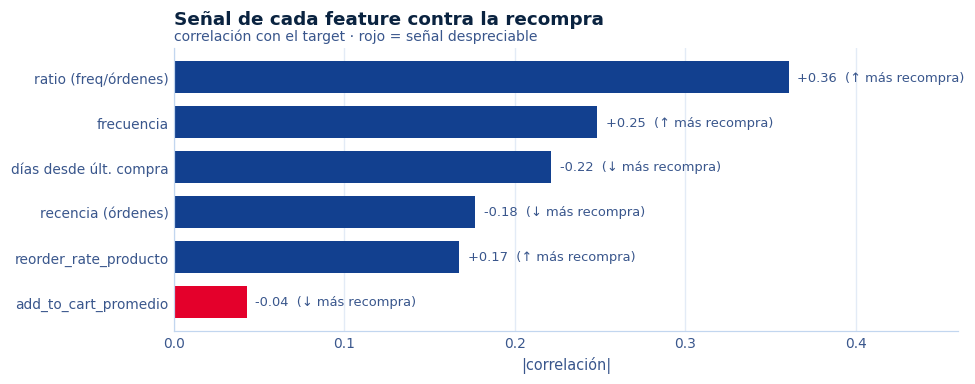

In [3]:
# Tabla etiquetada: interacciones de usuarios evaluables + etiqueta (está en el target)
con.execute("""CREATE OR REPLACE TABLE lab AS
SELECT i.freq_usuario_producto, i.recencia_usuario_producto, i.dias_registrados_desde_ultima_compra,
       i.add_to_cart_order_promedio, i.ultima_order_dow,
       u.cantidad_ordenes_historicas, u.segmento_usuario, u.dow_habitual, pr.reorder_rate_producto,
       CASE WHEN t.product_id IS NOT NULL THEN 1 ELSE 0 END AS y
FROM interacciones i JOIN usuarios u ON i.user_id=u.user_id JOIN productos pr ON i.product_id=pr.product_id
LEFT JOIN targets_train t ON i.user_id=t.user_id AND i.product_id=t.product_id
WHERE i.user_id IN (SELECT DISTINCT user_id FROM targets_train)""")
base = con.execute("SELECT AVG(y) FROM lab").fetchone()[0]
print(f"Pares evaluados: {con.execute('SELECT COUNT(*) FROM lab').fetchone()[0]:,}  ·  base rate de recompra: {base:.1%}")

corr = con.execute("""SELECT
  corr(freq_usuario_producto*1.0/cantidad_ordenes_historicas, y) "ratio (freq/órdenes)",
  corr(freq_usuario_producto, y) "frecuencia",
  corr(dias_registrados_desde_ultima_compra, y) "días desde últ. compra",
  corr(recencia_usuario_producto, y) "recencia (órdenes)",
  corr(reorder_rate_producto, y) "reorder_rate_producto",
  corr(add_to_cart_order_promedio, y) "add_to_cart_promedio"
FROM lab""").fetchdf().iloc[0]
señal = corr.abs().sort_values()

fig, ax = plt.subplots(figsize=(9,3.6))
cols = [ROJO if v<0.08 else AZUL for v in señal.values]
ax.barh(señal.index, señal.values, color=cols, height=.7)
for f,v in señal.items():
    signo = "↑ más recompra" if corr[f]>0 else "↓ más recompra"
    ax.text(v+0.005, f, f"{corr[f]:+.2f}  ({signo})", va="center", color=TINTA2, fontsize=8.5)
ax.set_xlim(0, 0.46)
ejes(ax, "Señal de cada feature contra la recompra", "correlación con el target · rojo = señal despreciable",
     xlab="|correlación|", grid="x")
plt.tight_layout(); guardar(fig,"eda2_01_señal_features"); plt.show()

figura → /sessions/tender-determined-rubin/mnt/outputs/reports/figures/eda2_02_prob_por_feature.png


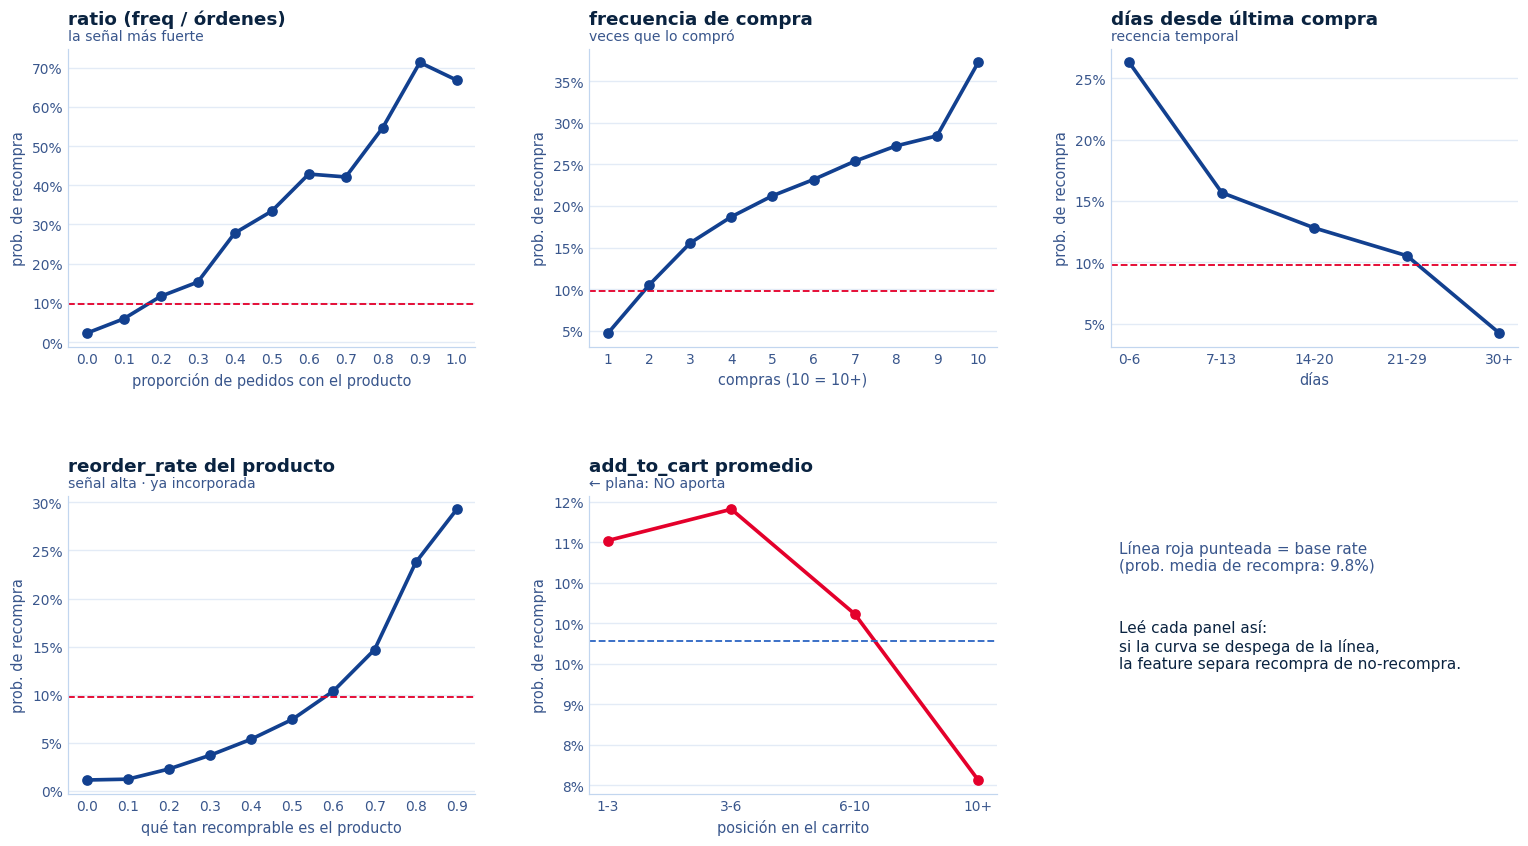

In [4]:
# Probabilidad de recompra según cada feature (curvas)
ratio = sql("SELECT ROUND(LEAST(freq_usuario_producto*1.0/cantidad_ordenes_historicas,1.0),1) b, AVG(y) p FROM lab GROUP BY 1 ORDER BY 1")
freq  = sql("SELECT CASE WHEN freq_usuario_producto>=10 THEN 10 ELSE freq_usuario_producto END b, AVG(y) p FROM lab GROUP BY 1 ORDER BY 1")
dias  = sql("""SELECT CASE WHEN dias_registrados_desde_ultima_compra>=30 THEN '30+' WHEN dias_registrados_desde_ultima_compra>=21 THEN '21-29'
               WHEN dias_registrados_desde_ultima_compra>=14 THEN '14-20' WHEN dias_registrados_desde_ultima_compra>=7 THEN '7-13' ELSE '0-6' END b,
               AVG(y) p, MIN(dias_registrados_desde_ultima_compra) o FROM lab GROUP BY 1 ORDER BY o""")
rrp   = sql("SELECT ROUND(reorder_rate_producto,1) b, AVG(y) p FROM lab WHERE reorder_rate_producto<=0.9 GROUP BY 1 ORDER BY 1")
atc   = sql("""SELECT CASE WHEN add_to_cart_order_promedio<3 THEN '1-3' WHEN add_to_cart_order_promedio<6 THEN '3-6'
               WHEN add_to_cart_order_promedio<10 THEN '6-10' ELSE '10+' END b, AVG(y) p, MIN(add_to_cart_order_promedio) o FROM lab GROUP BY 1 ORDER BY o""")

fig, ax = plt.subplots(2,3, figsize=(14,7.8))
def panel(a, x, y, titulo, sub, xlab, rojo=False):
    a.plot(range(len(x)), y, marker="o", color=(ROJO if rojo else AZUL), linewidth=2.4, markersize=6)
    a.axhline(base, color=ROJO if not rojo else AZUL_MED, linestyle="--", linewidth=1.2)
    a.set_xticks(range(len(x))); a.set_xticklabels(x, fontsize=8)
    a.yaxis.set_major_formatter(FuncFormatter(pct))
    ejes(a, titulo, sub, xlab=xlab, ylab="prob. de recompra")
panel(ax[0,0], ratio["b"], ratio["p"], "ratio (freq / órdenes)", "la señal más fuerte", "proporción de pedidos con el producto")
panel(ax[0,1], freq["b"], freq["p"], "frecuencia de compra", "veces que lo compró", "compras (10 = 10+)")
panel(ax[0,2], dias["b"], dias["p"], "días desde última compra", "recencia temporal", "días")
panel(ax[1,0], rrp["b"], rrp["p"], "reorder_rate del producto", "señal alta · ya incorporada", "qué tan recomprable es el producto")
panel(ax[1,1], atc["b"], atc["p"], "add_to_cart promedio", "← plana: NO aporta", "posición en el carrito", rojo=True)
ax[1,2].axis("off")
ax[1,2].text(0.02,0.75,"Línea roja punteada = base rate\n(prob. media de recompra: %.1f%%)"%(base*100),
             color=TINTA2, fontsize=10)
ax[1,2].text(0.02,0.42,"Leé cada panel así:\nsi la curva se despega de la línea,\nla feature separa recompra de no-recompra.",
             color=TINTA, fontsize=10)
plt.tight_layout(); plt.subplots_adjust(hspace=0.5, wspace=0.28); guardar(fig,"eda2_02_prob_por_feature"); plt.show()

> **→ Cómo seguir (para Juli)**
>
> - **Tus 3 features top están confirmadas por los datos** (no solo por el modelo): `ratio` (freq/órdenes,
>   corr 0,36), `frecuencia` (0,25) y `días desde última compra` (−0,22). Coincide con tu "3 variables
>   explican el 70%".
> - **Feature identificada por el EDA y ya incorporada al modelo: `reorder_rate_producto`** (corr 0,17). Sube la recompra de ~1% a ~29%
>   y es señal **propia del producto**, distinta de la popularidad (que vos medís en 0,9%). Es la
>   feature que el EDA identificó y que ya fue incorporada al modelo (PR de modelado).
> - **Las que NO conviene priorizar** (te ahorran tiempo): `add_to_cart_order_promedio` (corr −0,04,
>   curva plana) y día/hora habitual (~0). Para este target no separan.
> - **No linealidad:** `ratio` satura cerca de 0,9 y `frecuencia` sigue subiendo → LightGBM captura
>   eso mejor que la logística, coherente con tu +0,56 de "no linealidad e interacciones".


## 3. Dónde tiene margen el modelo (por segmento)

figura → /sessions/tender-determined-rubin/mnt/outputs/reports/figures/eda2_03_segmento.png


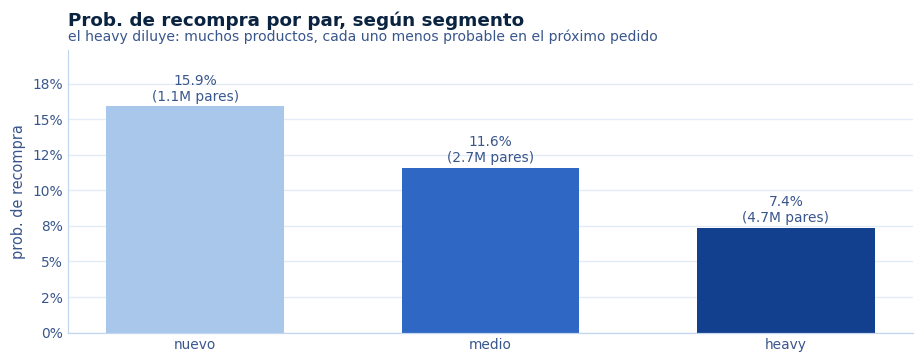

In [5]:
segp = sql("SELECT segmento_usuario s, AVG(y) p, COUNT(*) n FROM lab GROUP BY 1")
orden = {"nuevo":0,"medio":1,"heavy":2}; segp["o"]=segp["s"].map(orden); segp=segp.sort_values("o")
fig, ax = plt.subplots(figsize=(8.5,3.4))
ax.bar(segp["s"], segp["p"], color=[AZUL_CLARO,AZUL_MED,AZUL], width=.6)
for i,(p,n) in enumerate(zip(segp["p"],segp["n"])):
    ax.text(i, p+.004, f"{p:.1%}\n({n/1e6:.1f}M pares)", ha="center", color=TINTA2, fontsize=9)
ax.set_ylim(0, segp["p"].max()*1.25); ax.yaxis.set_major_formatter(FuncFormatter(pct))
ejes(ax, "Prob. de recompra por par, según segmento", "el heavy diluye: muchos productos, cada uno menos probable en el próximo pedido",
     ylab="prob. de recompra")
plt.tight_layout(); guardar(fig,"eda2_03_segmento"); plt.show()

> **→ Cómo seguir**
>
> El **nuevo** tiene la prob. por par más alta (16%) porque compra pocos productos y son sus básicos;
> el **heavy** la más baja (7%) por **dilución** (muchos productos, cada uno compite por entrar al
> Top-10). Consecuencia: el **modelo de ranking aporta más en heavy y medio** (hay muchos candidatos
> conocidos para ordenar), y a los **nuevos** los destraba el **descubrimiento** (productos que nunca
> compraron), no un mejor ranking de lo conocido. Coincide con tu "recompra captura 71% de lo
> alcanzable en nuevos vs 51% en heavy".


## 4. Cobertura y descubrimiento (para el dashboard de Leo)

Juli observó que la **cobertura de catálogo BAJA con los modelos** (0,45 → 0,39). No es un error: es
**esperado**. Como `reorder_rate_producto` tiene señal, los modelos se concentran en los productos más
recomprables (los básicos), y por eso tocan menos catálogo.

**La conclusión clave:** la cobertura **no** mide descubrimiento. Un modelo mejor de recompra va a
bajar la cobertura *y estar bien*. La historia de descubrimiento se mide aparte, con **Recall@10 de
novedad** (solo sobre productos que el usuario nunca compró) + tasa de novedad, no con cobertura.
Ver `analisis_resultados_y_metricas.md`.


## 5. Control cualitativo — ¿tienen sentido las recomendaciones?

*Tres usuarios ejemplo (uno por segmento): su Top-10 de recompra (productos conocidos rankeados por
ratio, recencia y frecuencia) vs. lo que realmente compraron en su próximo pedido.*

In [6]:
users = con.execute("""
  WITH tsz AS (SELECT user_id, COUNT(*) n FROM targets_train GROUP BY user_id),
       u AS (SELECT us.user_id, us.segmento_usuario seg, t.n FROM usuarios us
             JOIN tsz t ON us.user_id=t.user_id WHERE t.n BETWEEN 6 AND 10)
  SELECT seg, MIN(user_id) uid FROM u GROUP BY seg""").fetchdf()
users["o"]=users["seg"].map({"nuevo":0,"medio":1,"heavy":2}); users=users.sort_values("o")

def caso(uid):
    info = con.execute(f"SELECT segmento_usuario, cantidad_ordenes_historicas FROM usuarios WHERE user_id={uid}").fetchone()
    top = con.execute(f"""SELECT c.product_name AS producto, i.freq_usuario_producto AS veces_comprado
        FROM interacciones i JOIN catalogo c USING(product_id) JOIN usuarios u ON i.user_id=u.user_id
        WHERE i.user_id={uid}
        ORDER BY (i.freq_usuario_producto*1.0/u.cantidad_ordenes_historicas) DESC,
                 i.recencia_usuario_producto ASC, i.freq_usuario_producto DESC LIMIT 10""").fetchdf()
    tgt = set(con.execute(f"SELECT c.product_name FROM targets_train t JOIN catalogo c USING(product_id) WHERE t.user_id={uid}").fetchdf()["product_name"])
    n_tgt = con.execute(f"SELECT COUNT(*) FROM targets_train WHERE user_id={uid}").fetchone()[0]
    n_new = con.execute(f"SELECT COUNT(*) FROM targets_train WHERE user_id={uid} AND reordered=0").fetchone()[0]
    top.insert(0,"rank",range(1,len(top)+1))
    top["en_su_proximo_pedido"]=top["producto"].apply(lambda p: "SI (acierto)" if p in tgt else "-")
    hits=int((top["en_su_proximo_pedido"]=="SI (acierto)").sum())
    print(f"Usuario {uid} | {info[0].upper()} | {info[1]} ordenes historicas")
    print(f"   Proximo pedido: {n_tgt} productos ({n_new} NUEVOS, nunca comprados) | Aciertos del Top-10: {hits}")
    display(top)
for uid in users["uid"]: caso(uid)

Usuario 5 | NUEVO | 4 ordenes historicas
   Proximo pedido: 9 productos (5 NUEVOS, nunca comprados) | Aciertos del Top-10: 2


,rank,producto,veces_comprado,en_su_proximo_pedido
0,1,Red Raspberries,4,-
1,2,Organic Blackberries,4,-
2,3,Plain Whole Milk Yogurt,3,-
3,4,Whole Vitamin D Milk,3,-
4,5,Organic Red Onion,2,-
5,6,Organic Grape Tomatoes,2,SI (acierto)
6,7,Snow Peas,2,-
7,8,Organic Soba,2,SI (acierto)
8,9,Uncured Genoa Salami,1,-
9,10,Large Organic Omega3 Brown Eggs,1,-


Usuario 49 | MEDIO | 8 ordenes historicas
   Proximo pedido: 6 productos (5 NUEVOS, nunca comprados) | Aciertos del Top-10: 0


,rank,producto,veces_comprado,en_su_proximo_pedido
0,1,Strawberries,2,-
1,2,Andouille Chicken & Turkey Sausage,2,-
2,3,Fancy Feast Wet Classic Chicken Feast Cat Food,1,-
3,4,Half & Half,1,-
4,5,Gluten Free Rice Chex,1,-
5,6,Coconut Milk,1,-
6,7,Asparation/Broccolini/Baby Broccoli,1,-
7,8,Tahitian Vanilla Bean Gelato,1,-
8,9,Mango Sorbet,1,-
9,10,Organic Gala Apples,1,-


Usuario 7 | HEAVY | 20 ordenes historicas
   Proximo pedido: 9 productos (1 NUEVOS, nunca comprados) | Aciertos del Top-10: 4


,rank,producto,veces_comprado,en_su_proximo_pedido
0,1,Lactose Free Fat Free Milk,13,SI (acierto)
1,2,Mexican Coffee,12,-
2,3,Vanilla Coffee Concentrate,11,SI (acierto)
3,4,Organic Strawberries,10,-
4,5,85% Lean Ground Beef,8,SI (acierto)
5,6,Original No Pulp 100% Florida Orange Juice,8,-
6,7,Organic Cucumber,7,-
7,8,Seedless Red Grapes,7,-
8,9,Organic Apple Slices,7,-
9,10,Raspberry Lemonade,6,SI (acierto)


> **→ Cómo seguir (lectura de negocio)**
>
> Las recomendaciones son **productos coherentes** (lácteos, frutas, café, huevos…), no ruido: el
> baseline tiene sentido de negocio. Y los tres casos ilustran el mensaje central:
>
> - **Caso fuerte (heavy):** repite mucho → acertamos varios de sus productos, y casi nada de su
>   próximo pedido era nuevo.
> - **Caso débil (medio):** su próximo pedido fue **casi todo nuevo** (cosas idiosincráticas: tortillas,
>   ketchup, gelatos) → 0 aciertos. Es territorio de **descubrimiento**, no de recompra.
> - **Caso mixto (nuevo):** la mitad de su próximo pedido eran productos nuevos → techo bajo.
>
> El modelo **brilla en usuarios repetitivos** y choca con un **techo** cuando el próximo pedido trae
> novedad. Por eso descubrir es difícil y **se mide aparte** (Recall@10 de novedad).


## 6. Síntesis — decisiones que habilita este EDA

| Tema | Hallazgo | Decisión |
|---|---|---|
| Features top | `ratio`, `frecuencia`, `días desde últ. compra` explican la mayor parte de la señal | Mantener (ya están en el modelo) |
| Feature del EDA, ya incorporada | `reorder_rate_producto` (corr 0,17), señal propia del producto | Incorporada al modelo (PR de modelado) |
| Features a descartar | `add_to_cart_promedio` y día/hora habitual: señal ~0 | No invertir tiempo en ellas |
| Forma de la señal | `ratio`/`frecuencia` no lineales y saturantes | Justifica boosting (LightGBM) sobre lineal |
| Segmentos | recompra por par: nuevo 16% / medio 12% / heavy 7% | Ranking aporta en heavy/medio; nuevos → candidatos |
| Cobertura | baja con los modelos (0,45→0,39), por concentración | No es descubrimiento; usar Recall@10 de novedad |

---
*EDA sobre `data/processed/` · DuckDB + pandas · figuras en `reports/figures/`.*


In [7]:
con.close(); print("Listo.")

Listo.
